In [1]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 60

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"

roots = [
    "SP_v1.4.6_leak_corr_A_fid_cell",
    "SP_v1.4.6_leak_corr_B_fid_cell",
    "SP_v1.4.6_leak_corr_C_fid_cell",
]

print(roots)

['SP_v1.4.6_leak_corr_A_fid_cell', 'SP_v1.4.6_leak_corr_B_fid_cell', 'SP_v1.4.6_leak_corr_C_fid_cell']


In [2]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [3]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1543
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_fid_cell/getdist_SP_v1.4.6_leak_corr_A_fid_cell.txt
Removed no burn in
1487
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_B_fid_cell/getdist_SP_v1.4.6_leak_corr_B_fid_cell.txt
Removed no burn in
1504
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_C_fid_cell/getdist_SP_v1.4.6_leak_corr_C_fid_cell.txt
Removed no burn in


In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


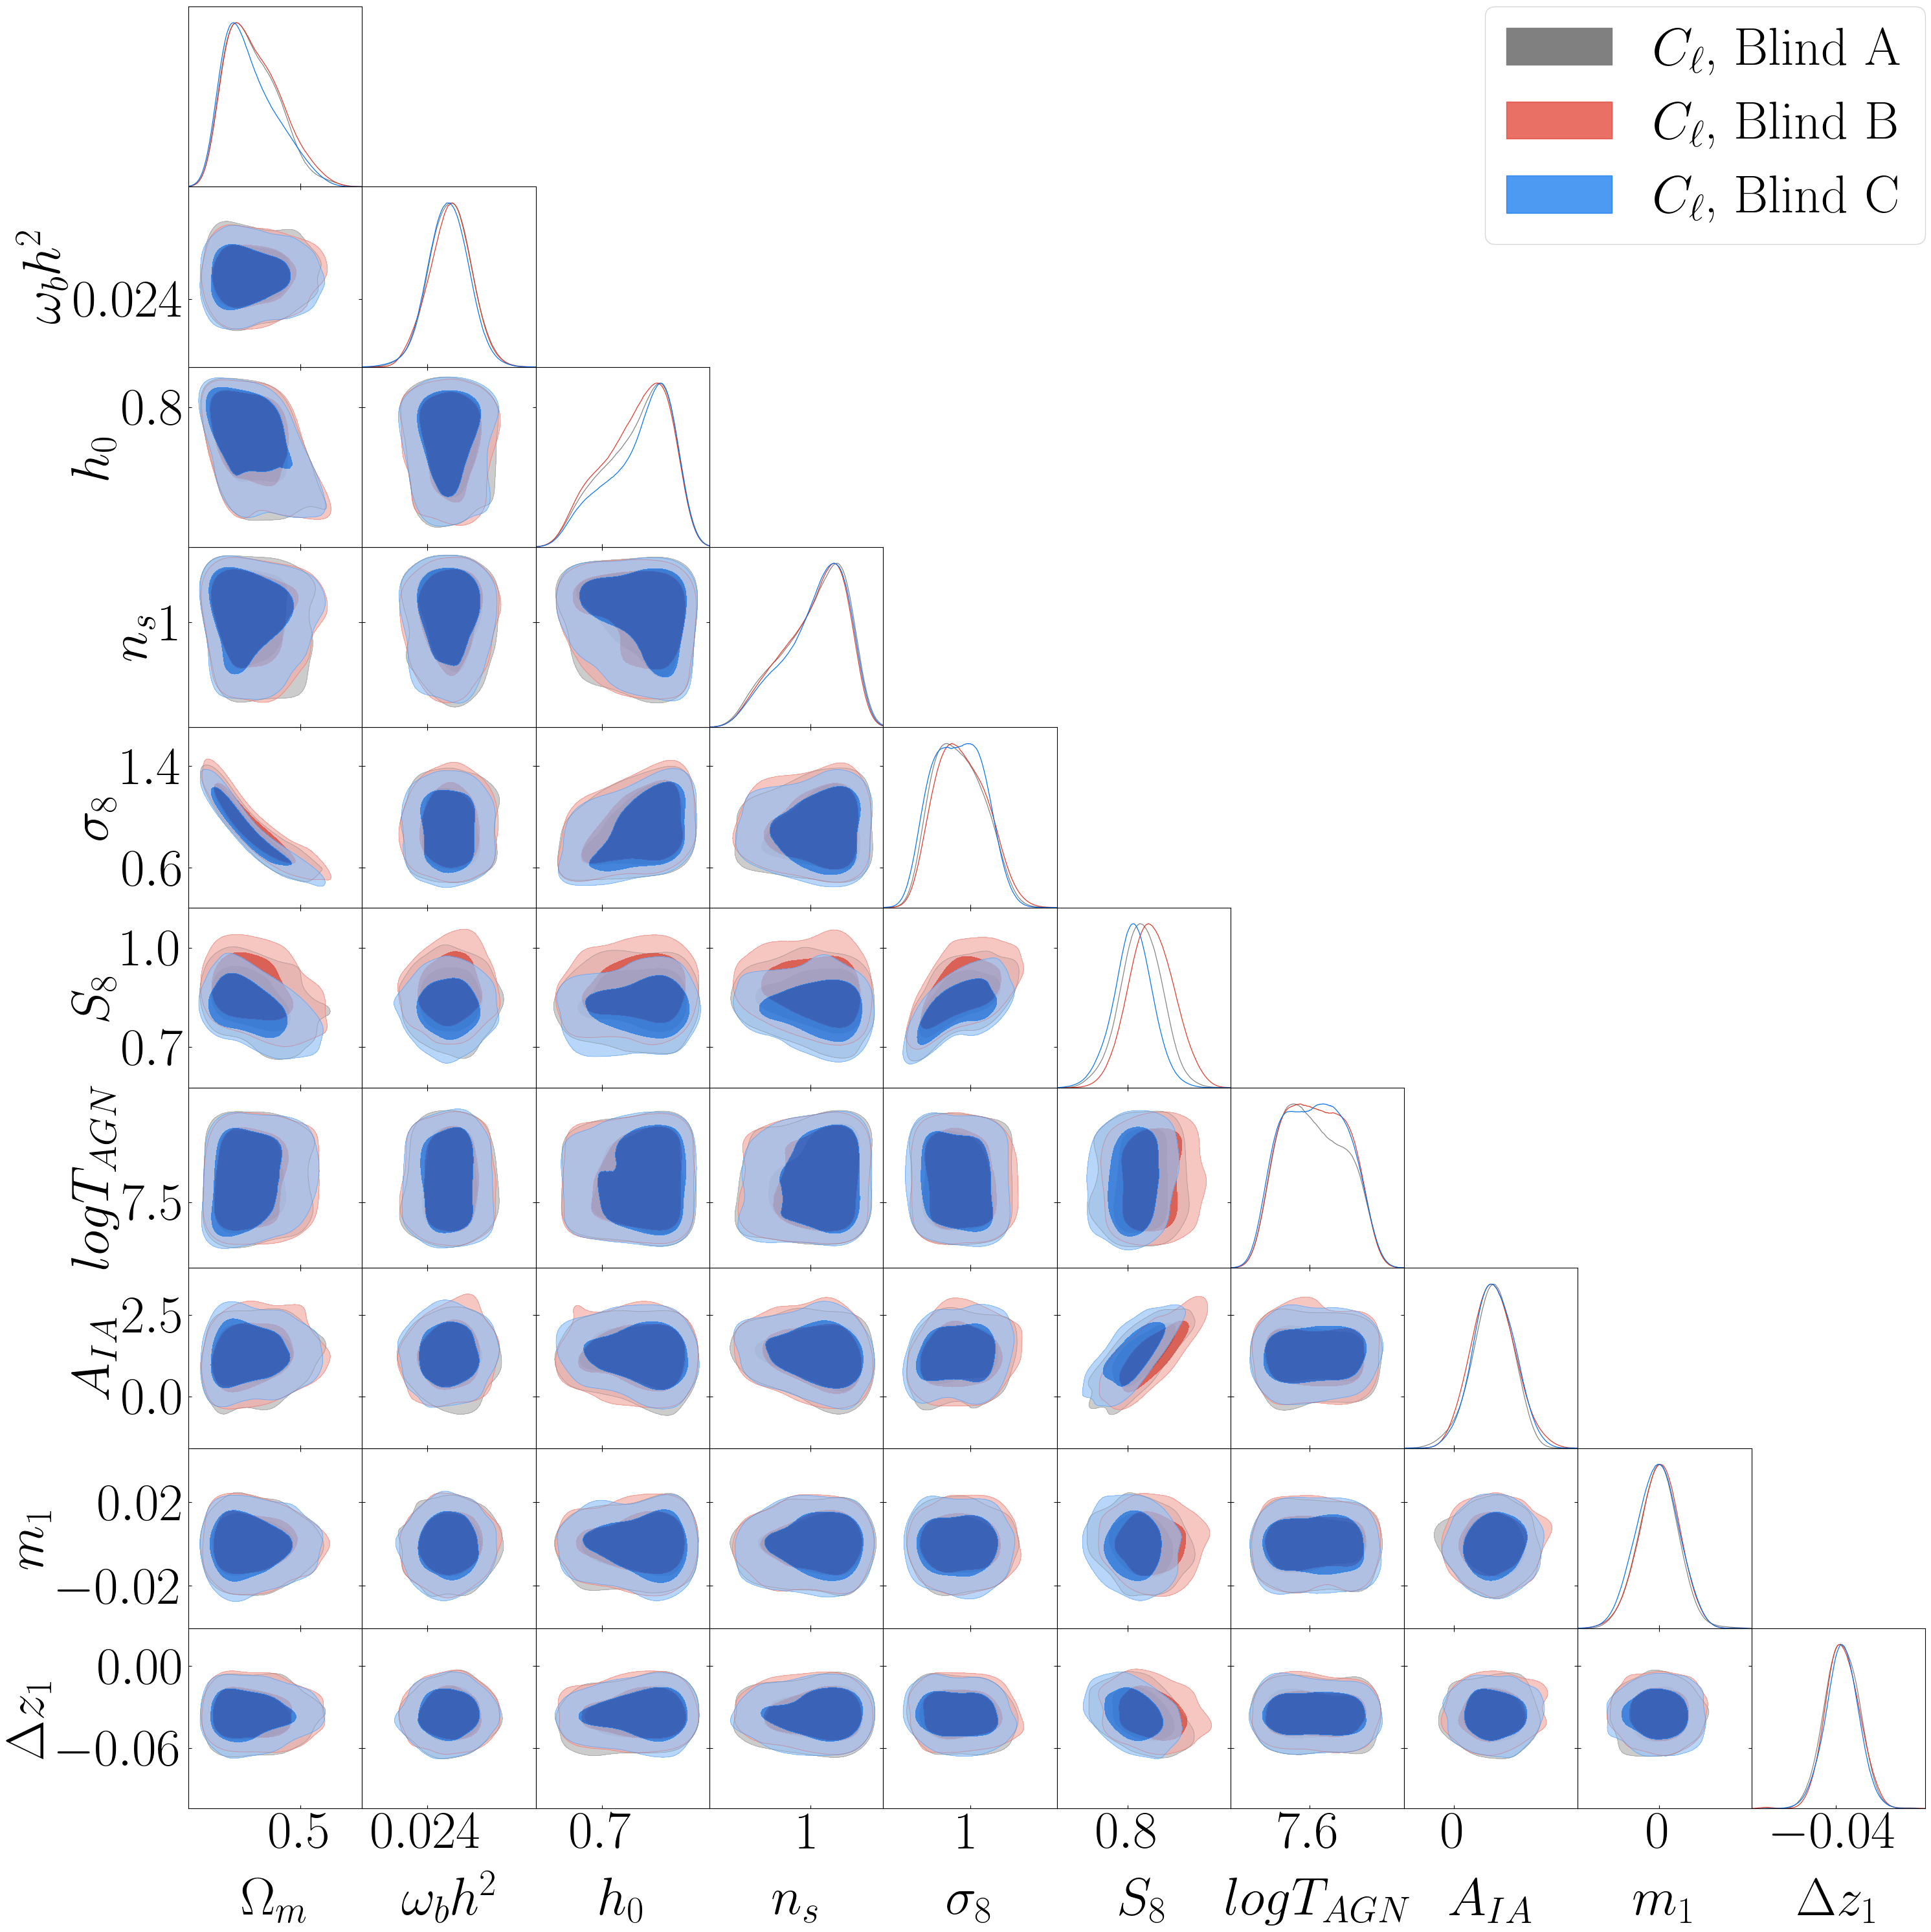

In [5]:
legend_labels = [
    r"$C_\ell$, Blind A",
    r"$C_\ell$, Blind B",
    r"$C_\ell$, Blind C",
]

#Plot all parameters
g.triangle_plot(
    chains,
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True
)

g.export('plots/contours_all_cell_blind.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


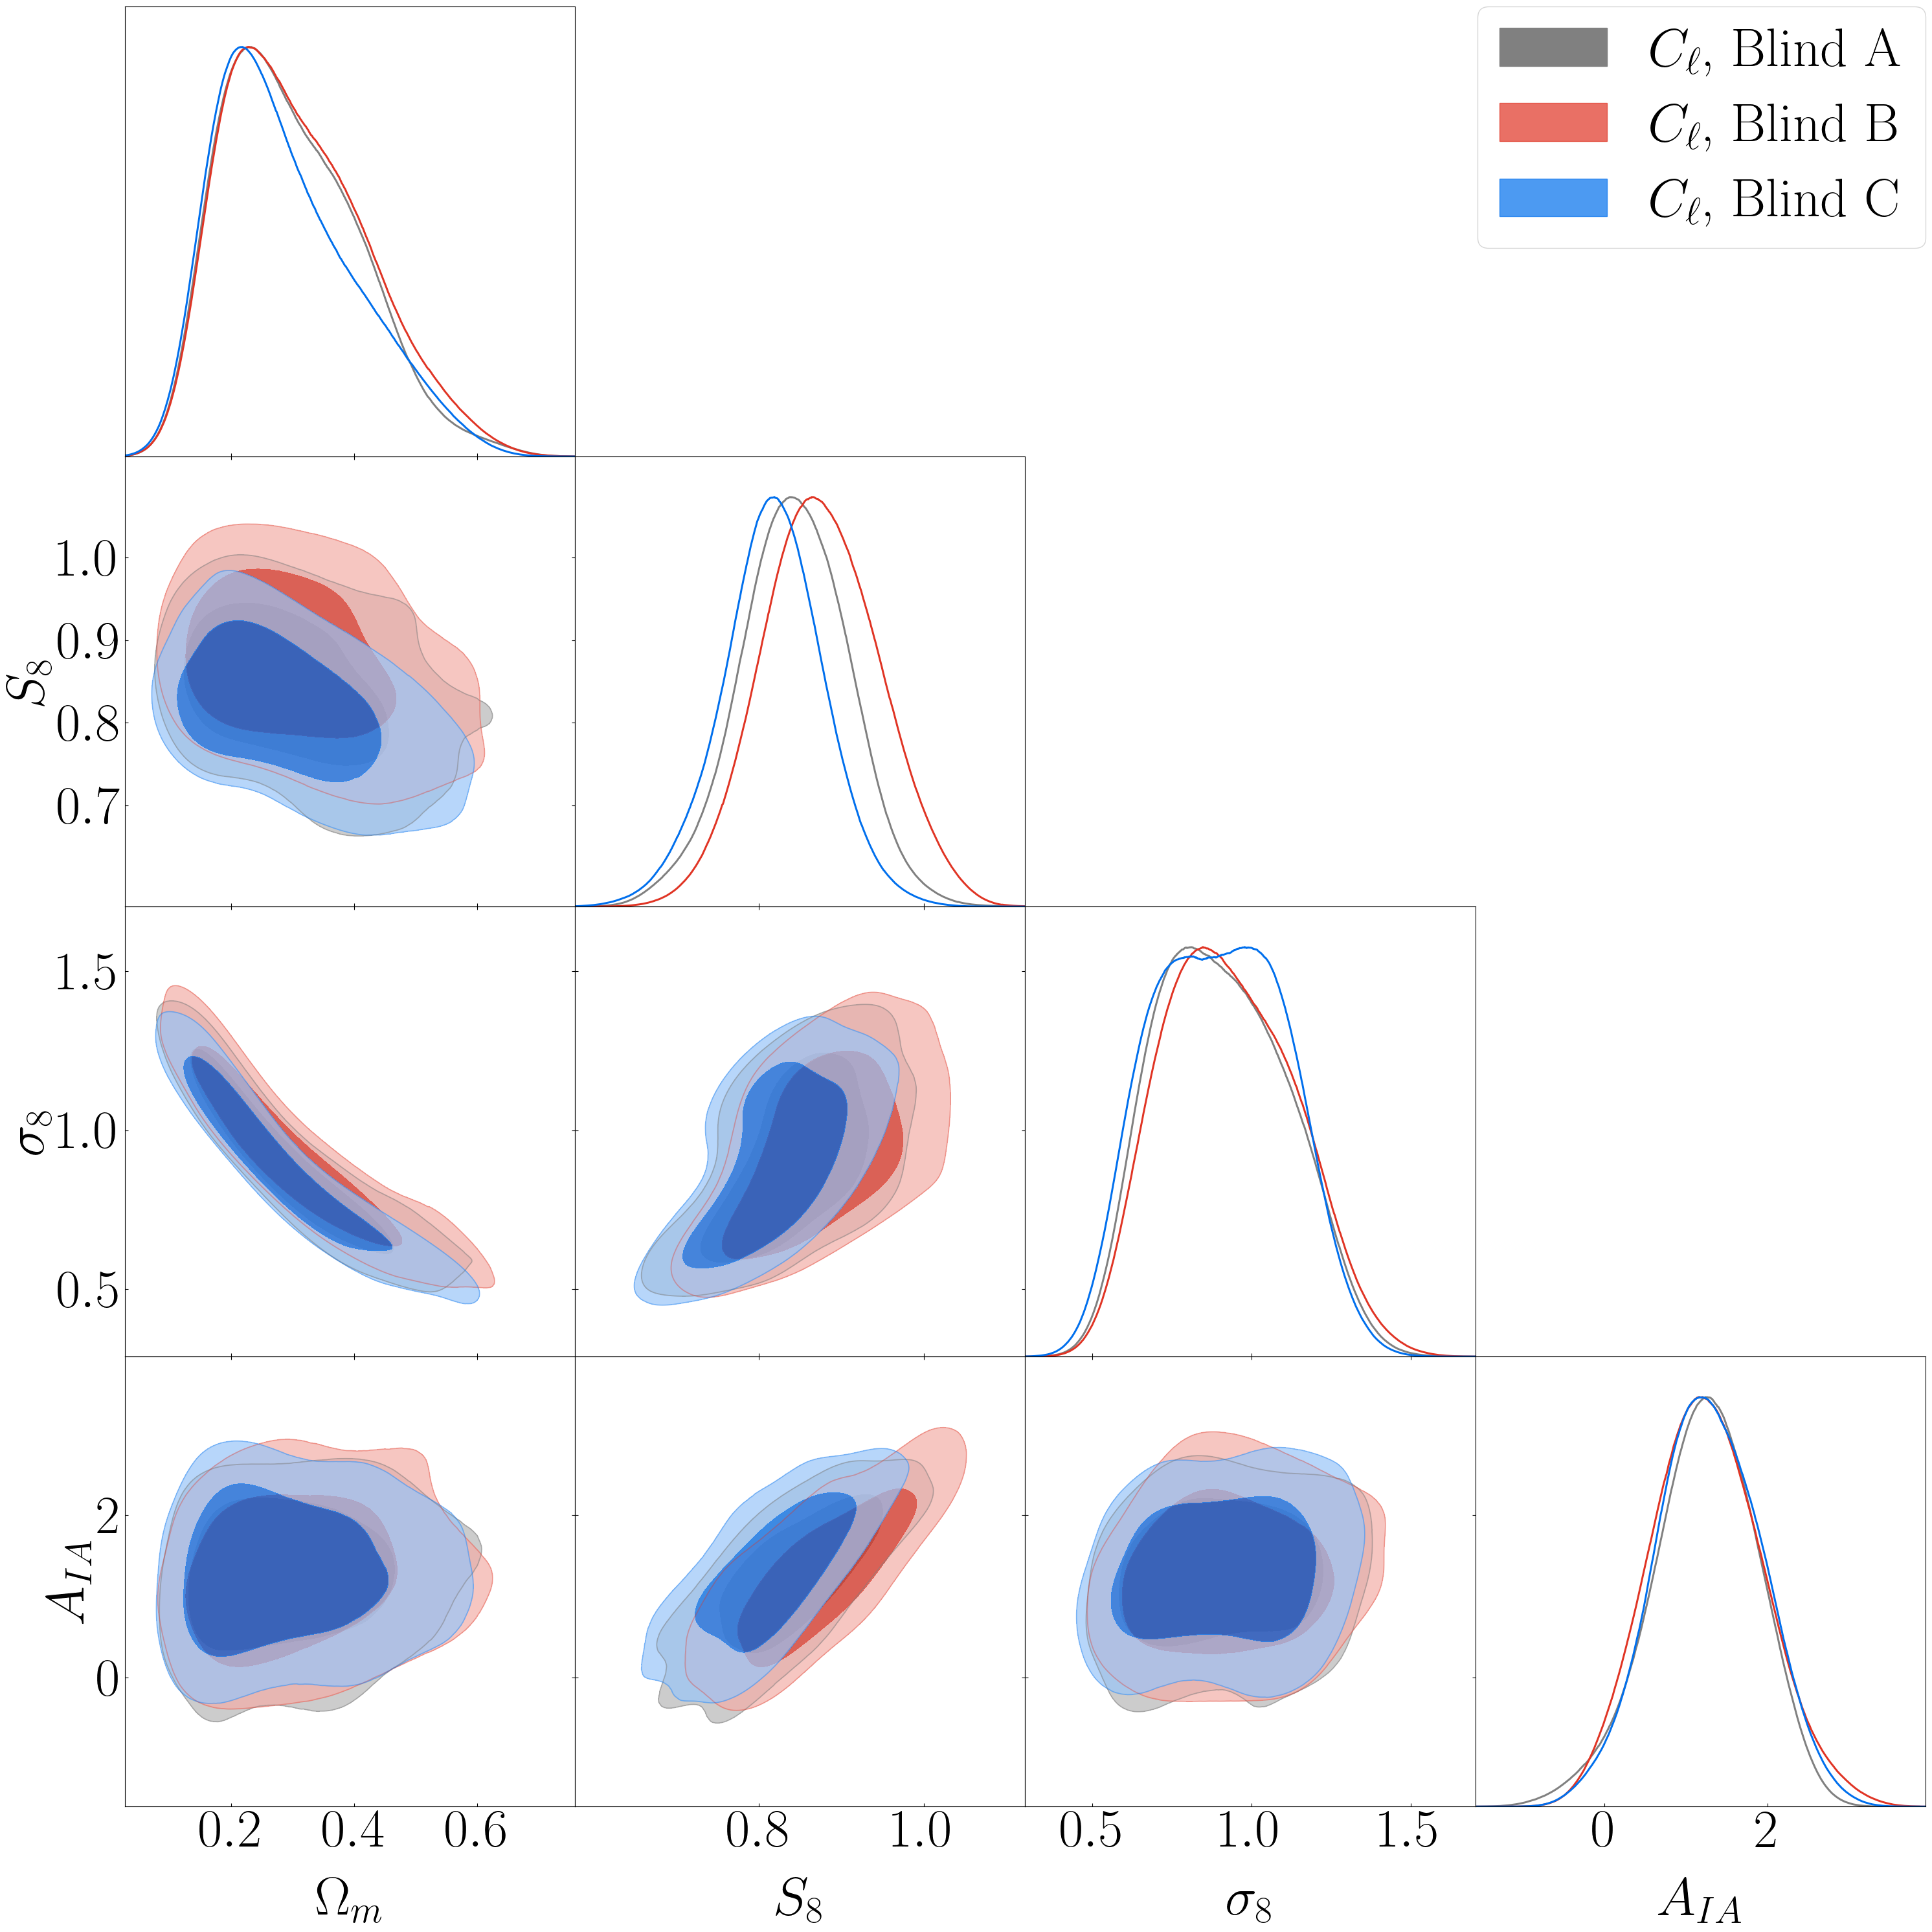

In [6]:
#Plot only cosmological parameters

g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True
)

g.export('plots/contours_cosmo_cell_blind.png')
plt.show()

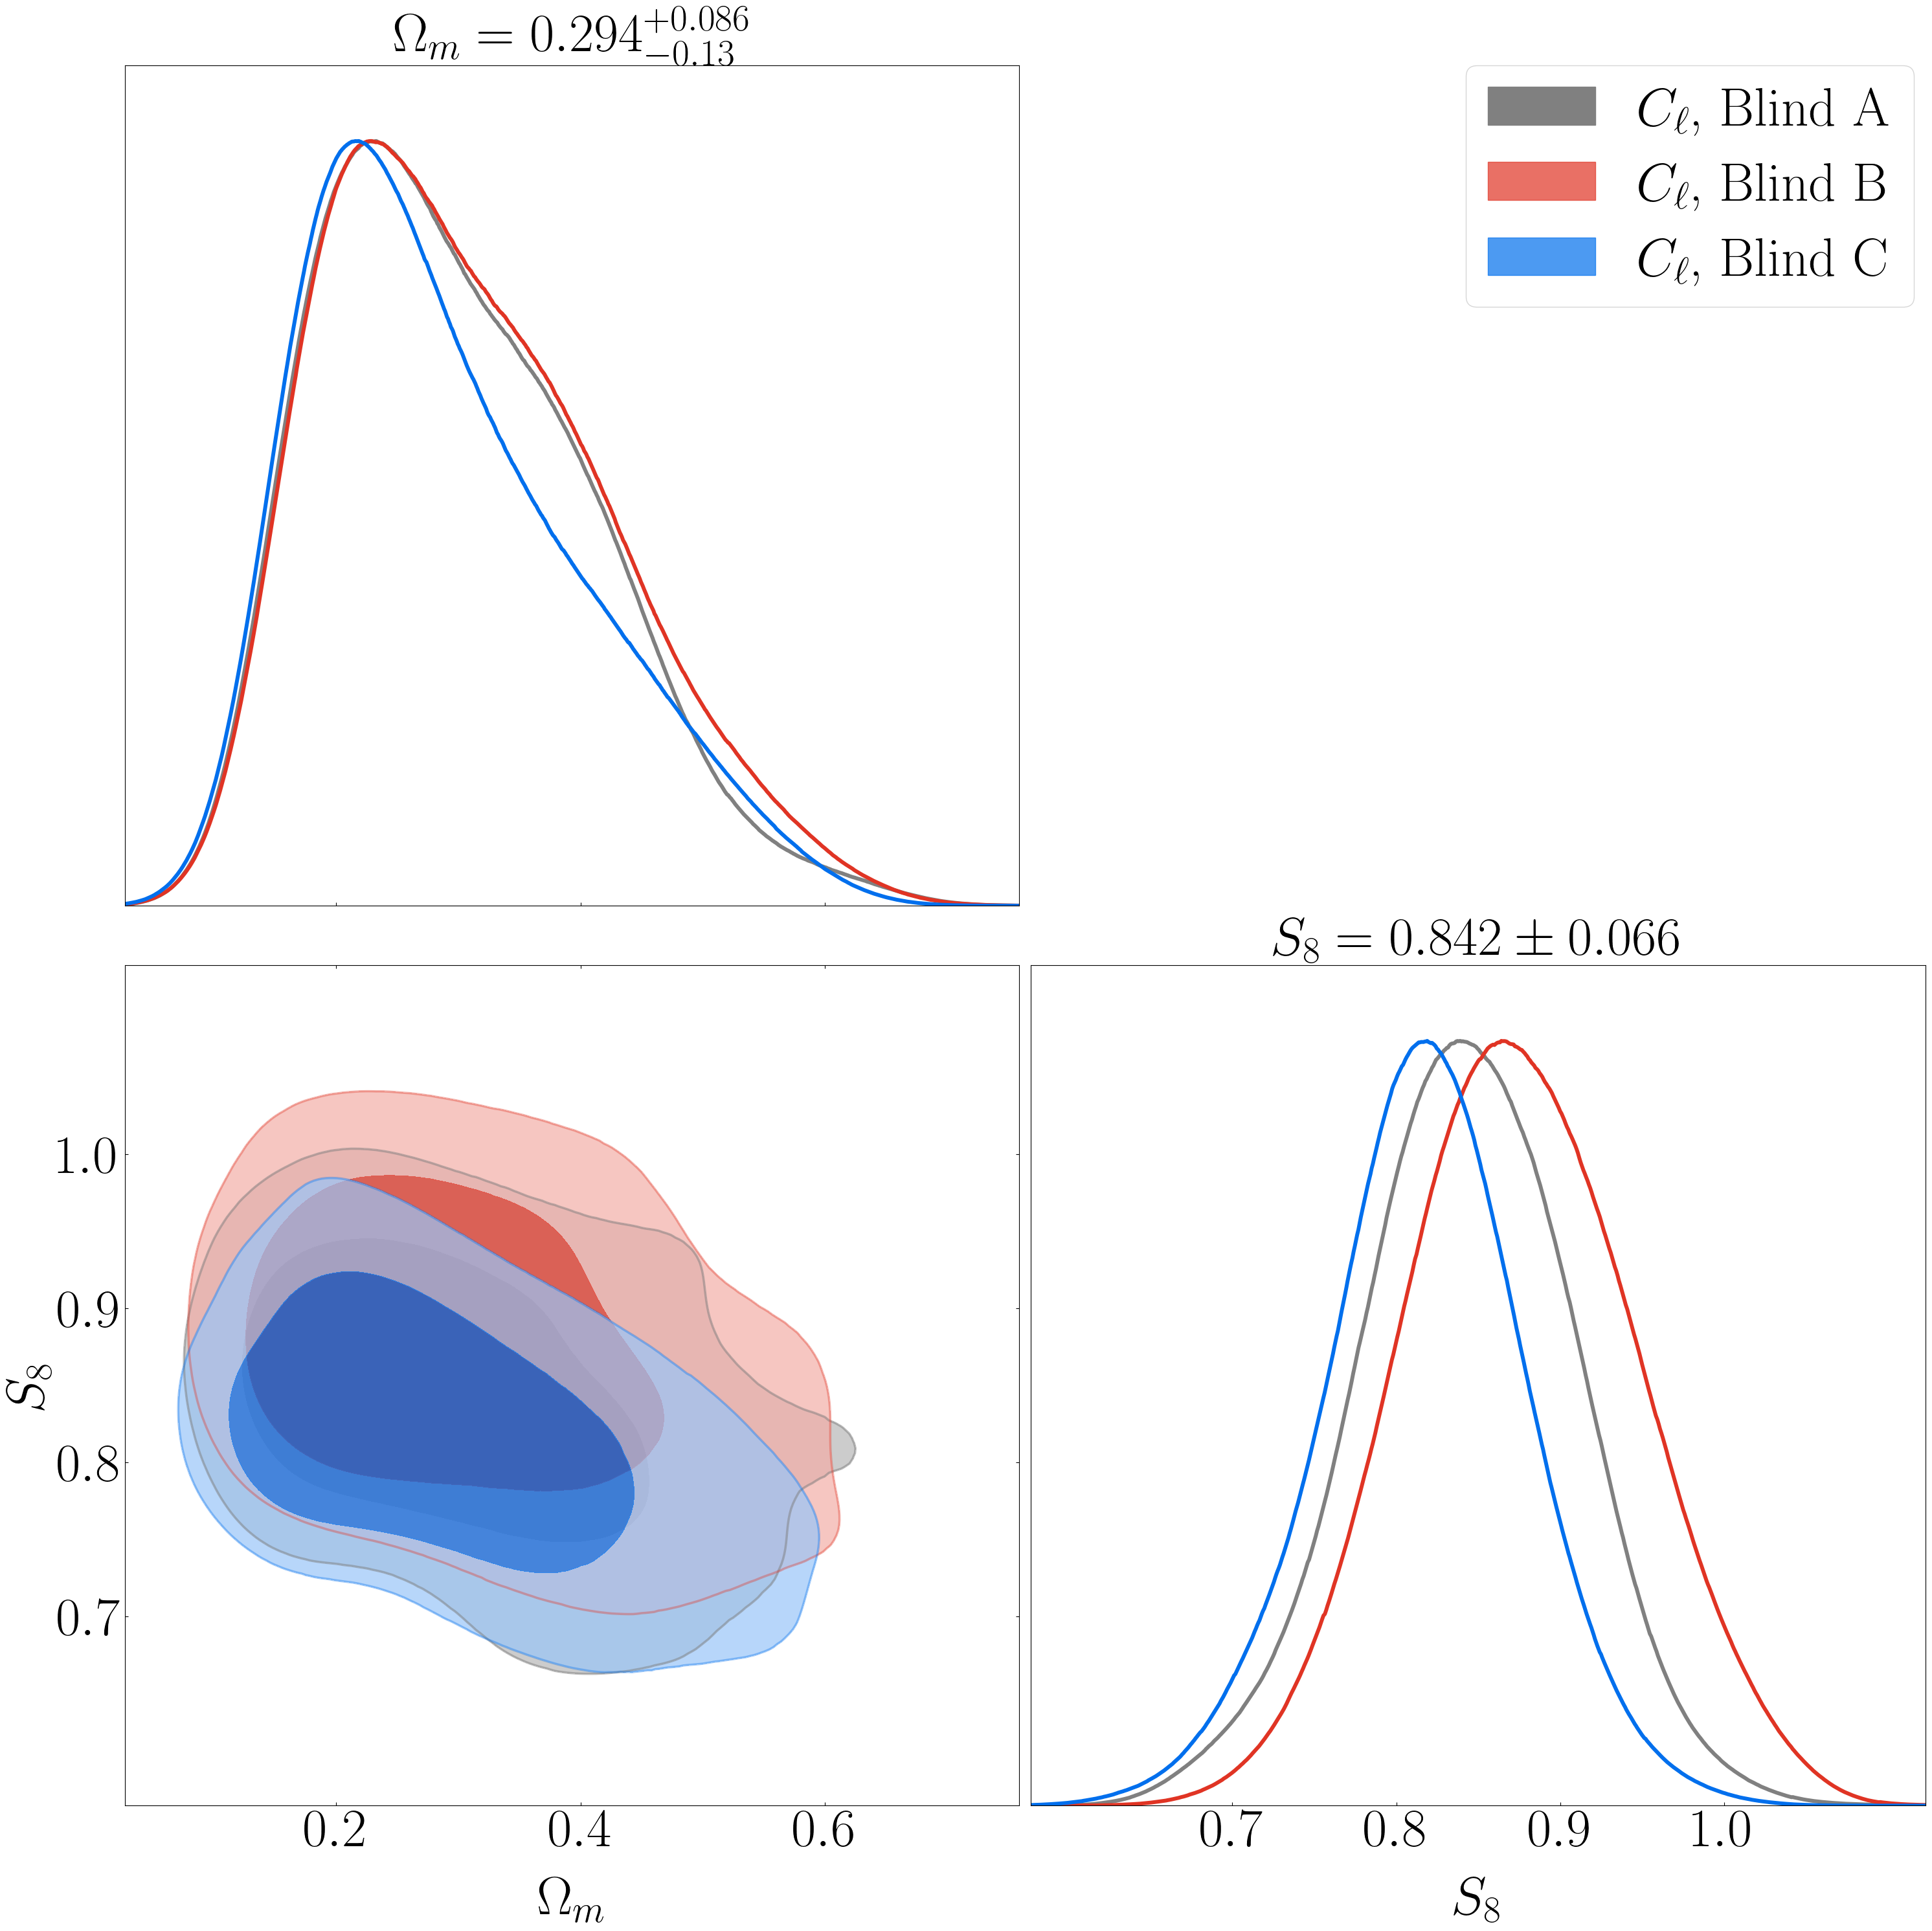

In [7]:
#Plot S8 Omega_m only
g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    filled=True,
    title_limit=1
)

""" plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330) """

g.export('plots/contours_s8_omegam_cell_blind.png')
plt.show()

In [12]:
s8_values = np.array(["# Expt", "Mean", "S8_low", "S8_high"])
for i, chain in enumerate(chains):

    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()

    param_stats = margestats.parWithName('S_8')
    
    s8_values = np.vstack((s8_values,[roots[i], param_stats.mean, param_stats.mean-param_stats.limits[0].lower, param_stats.limits[0].upper-param_stats.mean]))
print(s8_values)
np.savetxt(f"{root_dir}/S8_means.txt", s8_values, fmt=['%s','%s','%s','%s'], delimiter=',')

[['# Expt' 'Mean' 'S8_low' 'S8_high']
 ['SP_v1.4.5_cell' '0.8660210437751791' '0.04788908726791852'
  '0.05340030681970265']
 ['SP_v1.4.6_cell' '0.8474738646198369' '0.05742771222140697'
  '0.058332664056919725']
 ['SP_v1.4.8_cell' '0.829380801366315' '0.07028316663524692'
  '0.06884972521841104']
 ['SP_v1.4.5_leak_corr_cell' '0.8593083258591799' '0.06038613871588916'
  '0.06181426196363826']
 ['SP_v1.4.6_leak_corr_cell' '0.8377226862950229' '0.05635646018254359'
  '0.0628816988388754']
 ['SP_v1.4.8_leak_corr_cell' '0.8230227280171373' '0.07506272026931593'
  '0.07311581260334288']]


In [13]:
s8s = np.loadtxt(f"{root_dir}/S8_means.txt",dtype={'names': ('Expt', 's8_mean', 's8_low', 's8_high'), 'formats': ('U40', 'U20', 'U20', 'U20')}, skiprows=1, delimiter=',')
expt = s8s['Expt']
s8s_mean = s8s['s8_mean'].astype(np.float64)
s8s_low = s8s['s8_low'].astype(np.float64)
s8s_high = s8s['s8_high'].astype(np.float64)

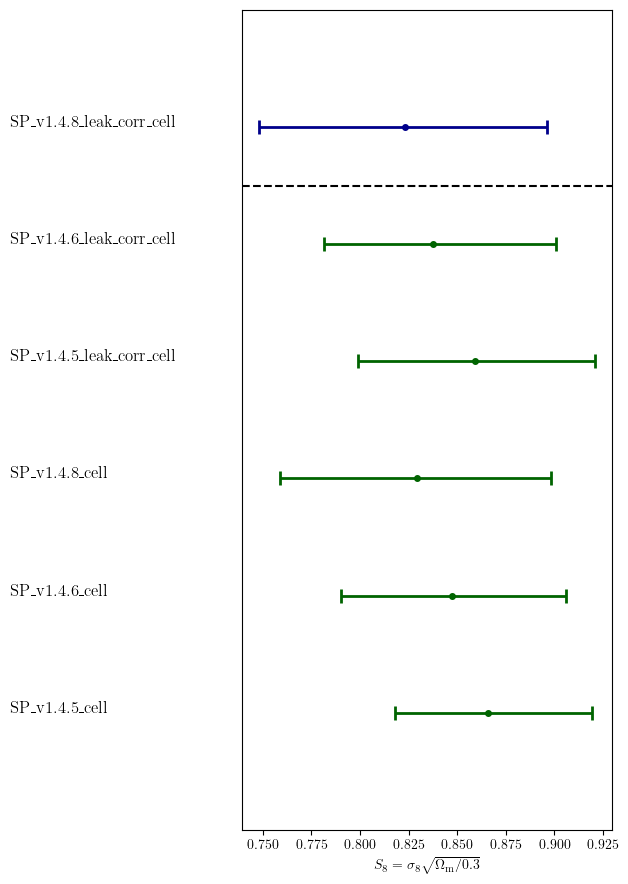

In [16]:
num_test_cases = 1

fig, axs = plt.subplots(1, 1, sharey=True, figsize=[7,1.5*len(expt)])
axs.yaxis.set_visible(False)

y = np.arange(0,len(expt))

for i in y:
    if i > len(expt)-num_test_cases-1:
        axs.errorbar(s8s_mean[i], i+1, xerr=np.vstack((s8s_low[i],s8s_high[i])), fmt='o', c = 'darkblue',lw = 2, capsize=5,capthick=2)
    else:
        axs.errorbar(s8s_mean[i], i+1, xerr=np.vstack((s8s_low[i],s8s_high[i])), fmt='o', c = 'darkgreen',lw = 2, capsize=5,capthick=2)
        
    """ if i == 0:        # Plot the band for "Planck"
        axs.axvspan(s8s_mean[i]-s8s_low[i], s8s_mean[i]+s8s_high[i], alpha=0.2, color='cyan')
    if i == len(expt)-1:        # Plot the band for "this work"
        axs.axvspan(s8s_mean[i]-s8s_low[i], s8s_mean[i]+s8s_high[i], alpha=0.2, color='lightpink')"""
    if i == len(expt)-num_test_cases-1: # Make a distinction between this work (and all its test cases) with external datasets
        axs.axhline(i+1.5, ls='dashed',c='k') 
    
    
    axs.set_xlabel(r'$S_8=\sigma_8\sqrt{\Omega_{\rm m}/0.3}$')    
    axs.text(0.62, i+1, rf"{expt[i]}")

plt.ylim([0,i+2])
plt.savefig("./plots/S8_whisker.png")